In [4]:
# IMPORTING LIBRARIES

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# LOADING DATA
#BETH DATASET IS USED
df_train = pd.read_csv('labelled_training_data.csv')
df_test = pd.read_csv('labelled_testing_data.csv')

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

# DATA CLEANING

drop_cols = ["timestamp", "stackAddresses", "args"]
df_train.drop(columns=drop_cols, inplace=True, errors='ignore')
df_test.drop(columns=drop_cols, inplace=True, errors='ignore')

# LABEL DEFINITION

df_train["label"] = ((df_train["sus"] == 1) | (df_train["evil"] == 1)).astype(int)
df_test["label"] = ((df_test["sus"] == 1) | (df_test["evil"] == 1)).astype(int)

df_train.drop(columns=["sus", "evil"], inplace=True, errors='ignore')
df_test.drop(columns=["sus", "evil"], inplace=True, errors='ignore')

 #FEATURE ENGINEERING

df_train["user_process"] = df_train["userId"].astype(str) + "_" + df_train["processName"]
df_test["user_process"] = df_test["userId"].astype(str) + "_" + df_test["processName"]

for col in ["processId", "eventName", "processName"]:
    freq_map = df_train[col].value_counts(normalize=True).to_dict()
    df_train[f"{col}_freq"] = df_train[col].map(freq_map)
    df_test[f"{col}_freq"] = df_test[col].map(freq_map).fillna(0)

# SPLITTING

X_train = df_train.drop("label", axis=1)
y_train = df_train["label"]

X_test = df_test.drop("label", axis=1)
y_test = df_test["label"]

# PREPROCESSING and MODEL

categorical_cols = ["processName", "hostName", "eventName", "user_process"]
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=5, sparse_output=False), categorical_cols),
    ]
)

model = RandomForestClassifier(
    n_estimators=250,
    max_depth=25,
    min_samples_split=4,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", model)
])

# TRAINNING

pipeline.fit(X_train, y_train)

# PREDICTING

y_probs = pipeline.predict_proba(X_test)[:, 1]
threshold = 0.25
y_pred = (y_probs >= threshold).astype(int)

# EVALUATION

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

#ANOMALY DETECTION

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

iso = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
)

iso.fit(X_train_processed)

anomaly_scores = -iso.decision_function(X_test_processed)

anomaly_scores = (anomaly_scores - anomaly_scores.min()) / \
                 (anomaly_scores.max() - anomaly_scores.min())

# RISK SCORE AND PRIORITY

risk_score = 0.7 * y_probs + 0.3 * anomaly_scores

final_output = df_test.copy()
final_output["Risk_Score"] = risk_score

# Assign priority levels
def assign_priority(score):
    if score >= 0.8:
        return "High"
    elif score >= 0.5:
        return "Medium"
    else:
        return "Low"

final_output["Priority"] = final_output["Risk_Score"].apply(assign_priority)

# SORTTING AND DISPLAY

ranked_alerts = final_output.sort_values(by="Risk_Score", ascending=False)

# Remove duplicate patterns
ranked_alerts = ranked_alerts.drop_duplicates(subset=["processName", "eventName"])

# Final display columns
display_cols = ["processId", "processName", "eventName", "Risk_Score", "Priority"]

print("\n=== Top 10 High-Risk Alerts ===")
print(ranked_alerts[display_cols].head(50))

Train shape: (763144, 16)
Test shape: (188967, 16)

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.75      0.70      0.73     17508
           1       0.97      0.98      0.97    171459

    accuracy                           0.95    188967
   macro avg       0.86      0.84      0.85    188967
weighted avg       0.95      0.95      0.95    188967

=== Confusion Matrix ===
[[ 12315   5193]
 [  4127 167332]]

=== Top 10 High-Risk Alerts ===
       processId      processName              eventName  Risk_Score Priority
1652         879          systemd             getdents64    0.985999     High
1700         879          systemd     sched_process_exit    0.951403     High
1484         879          systemd                  lstat    0.949913     High
1379         879          systemd                   stat    0.948832     High
1486         879          systemd  security_inode_unlink    0.935958     High
1475         879          syst

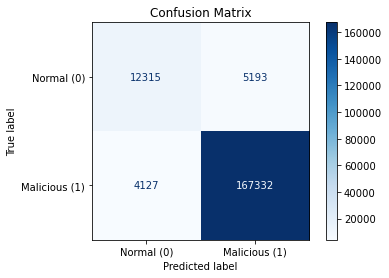

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# This will generate a nice graphic with labels
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Normal (0)", "Malicious (1)"], cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()